In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris

from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans

In [ ]:
df=load_iris(as_frame=True).frame


df


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [ ]:
X = df[['sepal length (cm)','sepal width (cm)']]
X.head()

,sepal length (cm),sepal width (cm)
0,5.1,3.5
1,4.9,3.0
2,4.7,3.2
3,4.6,3.1
4,5.0,3.6


In [ ]:
scaler=StandardScaler()

X_scaled = scaler.fit_transform(X)

In [ ]:
kmeans = KMeans(n_clusters=3,
                init = 'k-means++',
                max_iter = 400,
                random_state=42)

In [ ]:
kmeans.fit(X_scaled)

KMeans(max_iter=400, n_clusters=3, random_state=42)

In [ ]:
print(kmeans.labels_[:80])

[2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 1 2 2 2 2 2 2 2 2 0 0 0 1 0 1 0 1 0 1 1 1 1 1 1 0 1 1 1 1 0 1 1 1
 0 0 0 0 1 1]


In [ ]:
df['clusters'] =kmeans.labels_
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,clusters
0,5.1,3.5,1.4,0.2,0,2
1,4.9,3.0,1.4,0.2,0,2
2,4.7,3.2,1.3,0.2,0,2
3,4.6,3.1,1.5,0.2,0,2
4,5.0,3.6,1.4,0.2,0,2


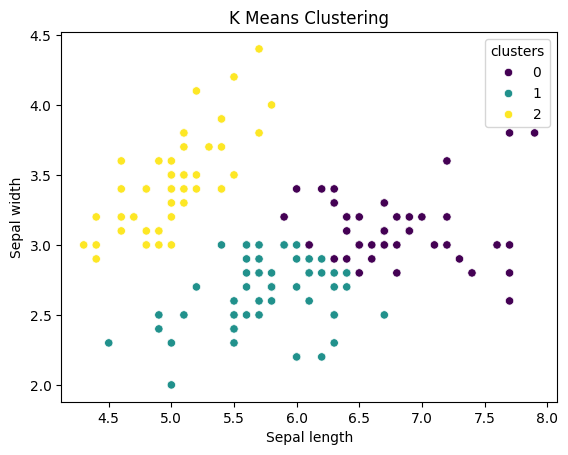

In [ ]:
sns.scatterplot(
    x = df['sepal length (cm)'],
    y = df['sepal width (cm)'],
    hue = df['clusters'],
    palette = 'viridis'
)

plt.title("K Means Clustering")
plt.xlabel("Sepal length")
plt.ylabel("Sepal width")
plt.show()

In [ ]:
print(f"Inertia: {kmeans.inertia_}")

Inertia: 102.62862638978044


# K-Means Clustering Short Note (Viva + Exam)

## 1. K-Means কী?

* K-Means একটি **Unsupervised Machine Learning Algorithm**।
* এটি কোনো **label/target ব্যবহার করে না**।
* Similar data point-গুলোকে একসাথে **Cluster** করে।

---

## 2. কেন এটি Unsupervised Learning?

**Answer:**

* K-Means-এ কোনো target বা label থাকে না।
* Model শুধুমাত্র feature-এর similarity (distance) দেখে cluster তৈরি করে।

---

## 3. এই কোডে কোন Feature ব্যবহার করা হয়েছে?

```python
X = df[['sepal length (cm)', 'sepal width (cm)']]
```

**Answer:**
শুধু দুটি feature ব্যবহার করা হয়েছে:

* Sepal Length
* Sepal Width

ব্যবহার করা হয়নি:

* Petal Length
* Petal Width
* Target

---

## 4. Dataset-এর বাকি Column কি Delete হয়ে গেছে?

**Answer:**
না। পুরো dataset `df`-এ আছে।
শুধু নতুন variable `X`-এ দুইটি column নেওয়া হয়েছে।

---

## 5. StandardScaler কেন ব্যবহার করা হয়েছে?

**Answer:**
K-Means Euclidean Distance ব্যবহার করে।
তাই সব feature-কে একই scale-এ আনার জন্য StandardScaler ব্যবহার করা হয়েছে।

---

## 6. `n_clusters=3` মানে কী?

**Answer:**
Dataset-কে ৩টি Cluster-এ ভাগ করবে।

---

## 7. `init='k-means++'` কী?

**Answer:**
Centroid ভালোভাবে নির্বাচন করার method।
এটি দ্রুত এবং ভালো clustering করতে সাহায্য করে।

---

## 8. `max_iter=400` মানে কী?

**Answer:**
Centroid সর্বোচ্চ 400 বার update হবে।
যদি আগে stable হয়ে যায়, তাহলে algorithm আগে থেকেই থেমে যাবে।

---

## 9. `random_state=42` কেন দেওয়া হয়?

**Answer:**
প্রতি রানেই একই result পাওয়ার জন্য।

---

## 10. `kmeans.labels_` কী?

**Answer:**
প্রতিটি data point কোন cluster-এ পড়েছে, সেই cluster number দেয়।

---

## 11. K-Means-এ Accuracy, Precision, Recall, F1-score কেন ব্যবহার করা হয় না?

**Answer:**
কারণ K-Means হলো Unsupervised Learning।
এখানে কোনো actual label নেই, তাই Accuracy বা F1-score হিসাব করা যায় না।

---

## 12. K-Means-এর Evaluation Metric কী?

**Answer:**

* Inertia ✅
* Silhouette Score
* Davies-Bouldin Index
* Calinski-Harabasz Score

---

## 13. Inertia কী?

**Answer:**
Inertia হলো প্রতিটি data point থেকে তার nearest centroid পর্যন্ত squared distance-এর মোট যোগফল।

**Lower Inertia = Better Clustering**

---

## 14. এই কোডে কী Measurement করা হয়েছে?

**Answer:**
শুধু **Inertia** বের করা হয়েছে।

```python
print(kmeans.inertia_)
```

---

# Viva Questions (One-Line Answers)

**Q: Is K-Means supervised or unsupervised?**

* K-Means is an **Unsupervised Learning Algorithm**.

**Q: Does K-Means use labels?**

* No, it does not use labels.

**Q: Why did you use StandardScaler?**

* To scale all features equally because K-Means uses Euclidean Distance.

**Q: Why only two columns?**

* To perform clustering and visualize the result easily in a 2D scatter plot.

**Q: What is Inertia?**

* It is the sum of squared distances between data points and their nearest centroid.

**Q: Lower Inertia means?**

* Better and more compact clusters.

**Q: Which evaluation metric did you use?**

* Inertia.
